In [1]:
import utils
from pathlib import Path
import os
import pandas as pd
import matplotlib.pyplot as plt

In [2]:
# extract the pathways for the NIBR dataset
path_rez = "../data/nibr/nibr"
path_set = Path(path_rez)
path_set.mkdir(exist_ok=True)
os.chdir(path_rez)

for patient in utils.patient_ids:
    utils.enrichent_results(utils.up_dict[patient], patient, 'NIBR_DRUGseq_2025_down')
os.chdir("../..")

In [3]:
# extract all the results from the folder where pvalue and FDR<0.05 
def build_dictionary(txt_dir):
    result = {}

    for txt_file in Path(txt_dir).glob("*.txt"):
        matches = set()

        with txt_file.open(encoding="utf-8") as f:
            for line in f:
                cols = line.rstrip("\n").split("\t")
                col1 = cols[0]

                try:
                    val2 = float(cols[2])
                    val3 = float(cols[3])
                except ValueError:
                    continue

                if val2 < 0.05 and val3 < 0.05:
                    matches.add(col1)

        result[txt_file.stem] = sorted(matches, key=str.lower)

    return result


In [4]:
# the cases when we have options in addition to those from the generic network; and viceversa, generic drugs that aren't in the individual lists
def differences_individ_general(general_list, dict_primary):
    general_set = set(general_list)
    n_general = len(general_set)
    without_result = 0
    results = {}
    percent_missing = []

    for key, values in dict_primary.items():
        values_set = set(values)
        if len(values_set)==0:
            without_result = without_result + 1

        not_in_general = values_set - general_set
        missing_from_general = general_set - values_set
        pct_missing = (len(missing_from_general) / n_general) * 100
        percent_missing.append(pct_missing)

        results[key] = {
            "not_in_general": list(not_in_general),
            "missing_from_general": list(missing_from_general),
            "no_not_in_general": len(not_in_general),
            "missing_from_general": len(missing_from_general)
        }
    
    counts = [v["no_not_in_general"] for v in results.values()]
    n_zero = sum(c == 0 for c in counts)
    non_zero_counts = [c for c in counts if c != 0]

    if non_zero_counts:
        min_val = min(non_zero_counts)
        max_val = max(non_zero_counts)
    else:
        min_val = max_val = None

    average_pct_missing = sum(percent_missing) / len(percent_missing)

    print("The number of cases without any solution",without_result )
    print("The number of cases that don't have drugs in addition to those resulted in the generic case:", n_zero)
    print("How many are in addition (if they are):", (min_val, max_val))   
    print("Average percent of drugs from generic analysis not suitable for individual cases:", average_pct_missing)


In [5]:
# Jaccard index between an individual case an the generic case (on same dataset)
def jaccard_calc_and_plot(general_list, dict_primary,name):

    general_set=set(general_list)
    jaccard_scores = {}
    
    for key, values in dict_primary.items():
        values_set = set(values)
        intersection = general_set & values_set
        union = general_set | values_set
        jaccard_scores[key] = len(intersection) / len(union)

    average_jaccard =  sum(jaccard_scores.values()) / len(jaccard_scores)
    print("The average Jaccard is", average_jaccard)

    n_cases = len(dict_primary)

    x = range(len(jaccard_scores))       
    y = list(jaccard_scores.values())

    plt.figure(figsize=(6,4))
    plt.rcParams['font.family'] = 'serif'
    plt.rcParams['font.serif'] = ['Times New Roman']
    plt.rcParams['font.size'] = 16
    plt.rcParams['font.weight'] = 'bold'
    plt.bar(x, y, color='skyblue')
    plt.xlabel("Case number", fontsize=16, fontfamily='Times New Roman', fontweight='bold')
    plt.ylabel("Jaccard index",fontsize=16, fontfamily='Times New Roman', fontweight='bold')
    plt.title(name+" - Jaccard index per case",fontsize=18, fontfamily='Times New Roman', fontweight='bold')
    plt.ylim(0, 1)

    label_interval = 10
    labels = [str(i) if i % label_interval == 0 else "" for i in x]
    plt.xticks(x, labels, rotation=90)

    plt.tight_layout()
    save_path = Path("../data/fig_res")
    save_path.mkdir(parents=True, exist_ok=True)
    plt.savefig(str(save_path)+"/jaccard"+name+".eps", dpi=500, bbox_inches='tight')
    plt.show()
        

The number of cases without any solution 27
The number of cases that don't have drugs in addition to those resulted in the generic case: 41
How many are in addition (if they are): (1, 1689)
Average percent of drugs from generic analysis not suitable for individual cases: 53.42622901588636
The average Jaccard is 0.3981060774837336


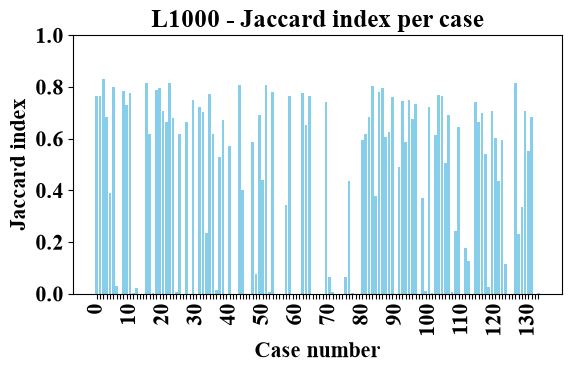

In [6]:
# results on L1000
enrichr_results = build_dictionary("./enrichr/enrichr")
dict_enrich = {k: v for k, v in enrichr_results.items() if k in utils.list_primary}
differences_individ_general(enrichr_results["all"],dict_enrich)
jaccard_calc_and_plot(enrichr_results["all"],dict_enrich,"L1000")

The number of cases without any solution 51
The number of cases that don't have drugs in addition to those resulted in the generic case: 60
How many are in addition (if they are): (1, 960)
Average percent of drugs from generic analysis not suitable for individual cases: 56.402699876414104
The average Jaccard is 0.21398292327073665


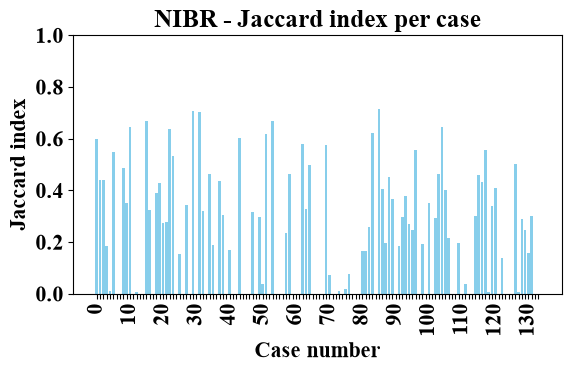

In [7]:
# results on NIBR
nibr_results = build_dictionary("./nibr/nibr")
dict_nibr = {k: v for k, v in nibr_results.items() if k in utils.list_primary}
differences_individ_general(nibr_results["all"],dict_nibr)
jaccard_calc_and_plot(nibr_results["all"],dict_nibr,"NIBR")

The number of cases without any solution 0
The number of cases that don't have drugs in addition to those resulted in the generic case: 0
How many are in addition (if they are): (7, 31)
Average percent of drugs from generic analysis not suitable for individual cases: 21.126382476108667
The average Jaccard is 0.6995943984228896


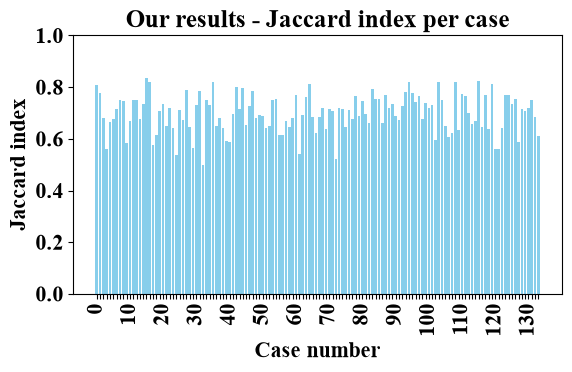

In [8]:
#extract the drugs from our results
df = pd.read_excel("drugs_for_each_case_in_one_sheet.xlsx")
df_primary = df[df["Patient"].isin(utils.list_primary)]

key_col = "Patient"  
value_col = "Drug"  

all_primary_results = (
    df_primary.dropna(subset=[key_col, value_col])
      .groupby(key_col)[value_col]
      .agg(list)
      .to_dict()
)
df_all = df[df["Patient"]=="all"]
general_list=df_all["Drug"].tolist()

differences_individ_general(general_list, all_primary_results)
jaccard_calc_and_plot(general_list, all_primary_results,"Our results")